In [1]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load dataset
df = pd.read_csv('synthetic_commercial_loans_final.csv')

In [3]:
exclude = ['Default', 'Loan_ID', 'Origination_Date', 'Borrower_ID']
feature_cols = [col for col in df.columns if col not in exclude and pd.api.types.is_numeric_dtype(df[col])]

X = df[feature_cols]
y = df['Default']

In [4]:
print("=== Feature Selection Results ===")

# 1. SelectKBest
kbest = SelectKBest(score_func=f_classif, k=15)
kbest.fit(X, y)
selected_kbest = [feature_cols[i] for i in kbest.get_support(indices=True)]
print("\nTop 15 Features (SelectKBest):", selected_kbest)

=== Feature Selection Results ===

Top 15 Features (SelectKBest): ['Loan_Amount', 'Interest_Rate', 'Loan_Term_Months', 'Debt_to_Equity', 'Current_Ratio', 'Collateral_Value', 'LTV_Ratio', 'Months_Since_Origination', 'Delinquency_Days', 'sales_growth_3m', 'days_past_due', 'gst_delay_days', 'cash_flow_3m_trend', 'cash_flow_6m_trend', 'industry_risk_score']


In [5]:
# 2. RFE
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=12)
rfe.fit(X, y)

C:\Anaconda\envs\AI\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):
C:\Anaconda\envs\AI\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):
C:\Anaconda\envs\AI\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):
C:\Anaconda\envs\AI\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if _joblib.__version__ >= LooseVersion('0.12'):
C:\Anaconda\envs\AI\lib\site-packages\sklearn\utils\fixes.py:230: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if 

RFE(estimator=RandomForestClassifier(bootstrap=True, class_weight=None,
                                     criterion='gini', max_depth=None,
                                     max_features='auto', max_leaf_nodes=None,
                                     min_impurity_decrease=0.0,
                                     min_impurity_split=None,
                                     min_samples_leaf=1, min_samples_split=2,
                                     min_weight_fraction_leaf=0.0,
                                     n_estimators=100, n_jobs=None,
                                     oob_score=False, random_state=42,
                                     verbose=0, warm_start=False),
    n_features_to_select=12, step=1, verbose=0)

In [6]:
selected_rfe = [feature_cols[i] for i in range(len(feature_cols)) if rfe.support_[i]]
print("\nTop 12 Features (RFE):", selected_rfe)


Top 12 Features (RFE): ['Loan_Amount', 'Credit_Score', 'Collateral_Value', 'LTV_Ratio', 'Delinquency_Days', 'annual_turnover', 'sales_growth_3m', 'days_past_due', 'gst_delay_days', 'cash_flow_3m_trend', 'cash_flow_6m_trend', 'industry_risk_score']


In [10]:
# Scale
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("PCA Components (95% variance):", pca.n_components_)
print("Explained Variance:", np.round(pca.explained_variance_ratio_[:5], 4))

PCA Components (95% variance): 17
Explained Variance: [0.1424 0.1136 0.0945 0.0592 0.0498]


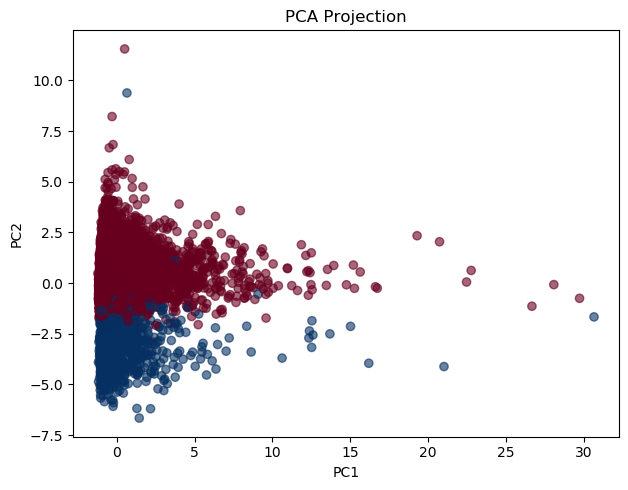

In [13]:
import matplotlib.pyplot as plt
# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Default'], cmap='RdBu', alpha=0.6)
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()

In [15]:
# Loadings Table (Feature Contributions)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=feature_cols
)

loadings.to_csv('pca_loadings_with_features.csv')
print("PCA Loadings with Feature Names saved to pca_loadings_with_features.csv")

# Preview Top Loadings for PC1
print("\nTop 10 Features Loading on PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10))

PCA Loadings with Feature Names saved to pca_loadings_with_features.csv

Top 10 Features Loading on PC1:
annual_turnover          0.577281
Annual_Revenue           0.577156
monthly_sales            0.575422
LTV_Ratio                0.021666
Current_Ratio            0.017244
Debt_Service_Coverage    0.016898
cash_flow_3m_trend       0.016778
Interest_Rate            0.016419
Loan_Amount              0.014796
sales_growth_3m          0.013403
Name: PC1, dtype: float64



Top 8 Features for PC1:
annual_turnover          0.5773
Annual_Revenue           0.5772
monthly_sales            0.5754
LTV_Ratio                0.0217
Current_Ratio            0.0172
Debt_Service_Coverage    0.0169
cash_flow_3m_trend       0.0168
Interest_Rate            0.0164
Name: PC1, dtype: float64


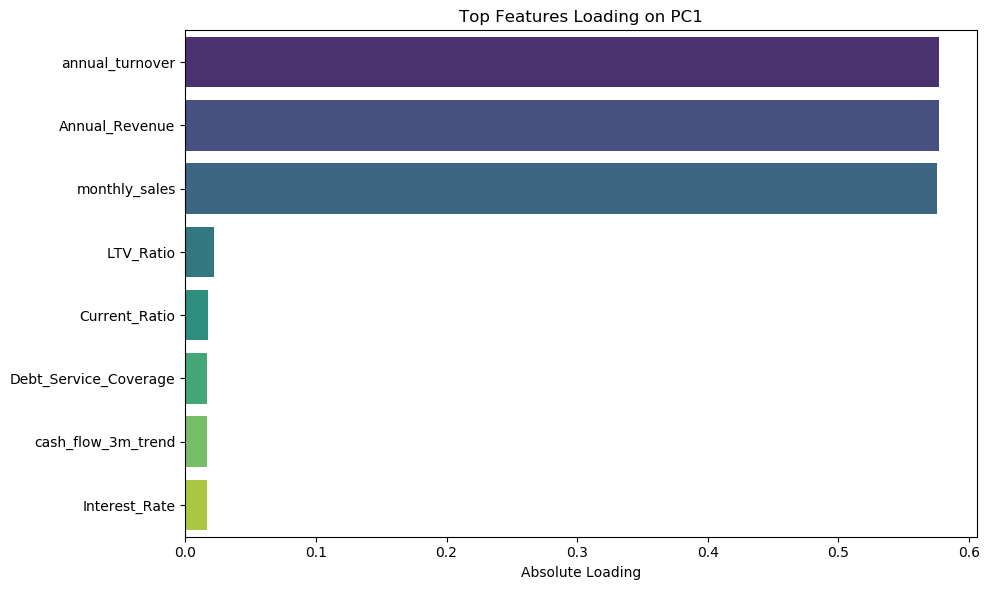


Top 8 Features for PC2:
Delinquency_Days         0.4665
days_past_due            0.4634
cash_flow_3m_trend       0.4415
gst_delay_days           0.2855
Debt_Service_Coverage    0.2626
LTV_Ratio                0.2540
Loan_Amount              0.2459
cash_flow_6m_trend       0.2184
Name: PC2, dtype: float64


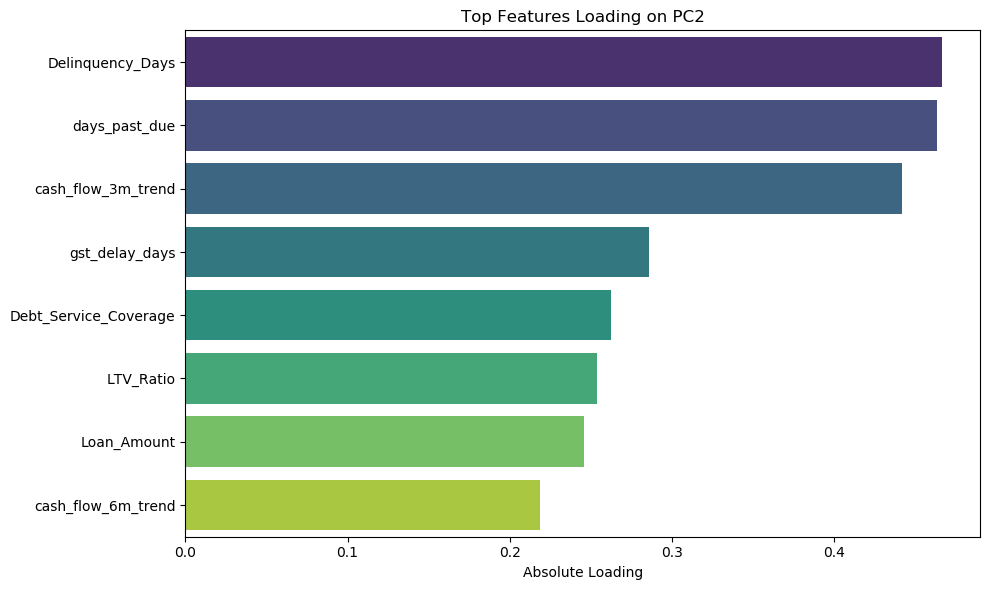


Top 8 Features for PC3:
Debt_Service_Coverage    0.4282
LTV_Ratio                0.4097
Loan_Amount              0.4019
Delinquency_Days         0.3525
days_past_due            0.3485
cash_flow_3m_trend       0.2960
gst_delay_days           0.2414
cash_flow_6m_trend       0.1840
Name: PC3, dtype: float64


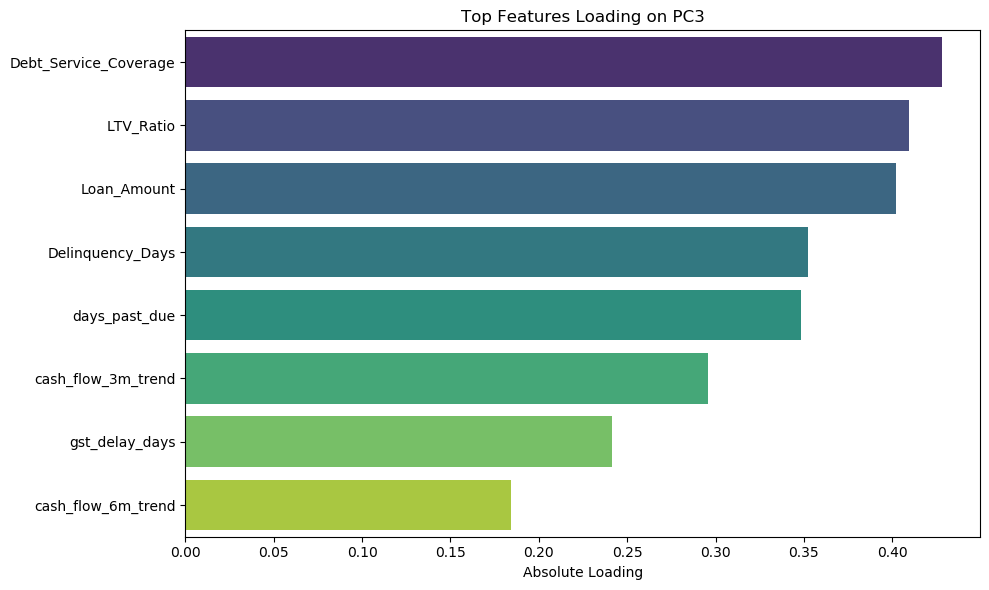


Top 8 Features for PC4:
Collateral_Value         0.7248
LTV_Ratio                0.4575
Debt_Service_Coverage    0.3245
Loan_Amount              0.2711
Loan_Term_Months         0.2107
EBITDA                   0.1774
Interest_Rate            0.0635
cash_flow_3m_trend       0.0541
Name: PC4, dtype: float64


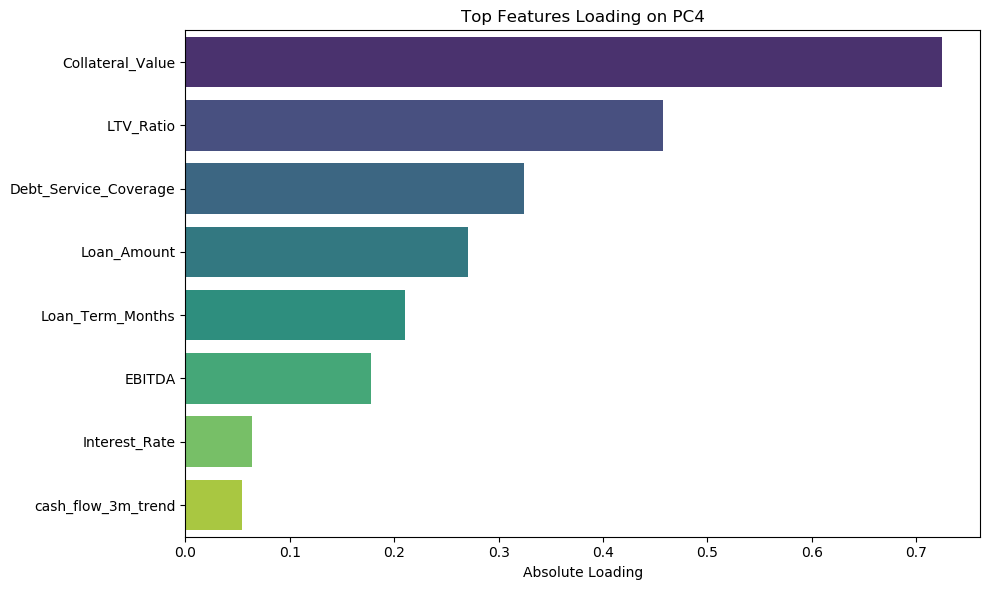


Top 8 Features for PC5:
EBITDA                 0.5450
Interest_Rate          0.3883
Loan_Term_Months       0.3800
Credit_Score           0.3226
Current_Ratio          0.2666
industry_risk_score    0.2499
Collateral_Value       0.2257
Loan_Amount            0.2036
Name: PC5, dtype: float64


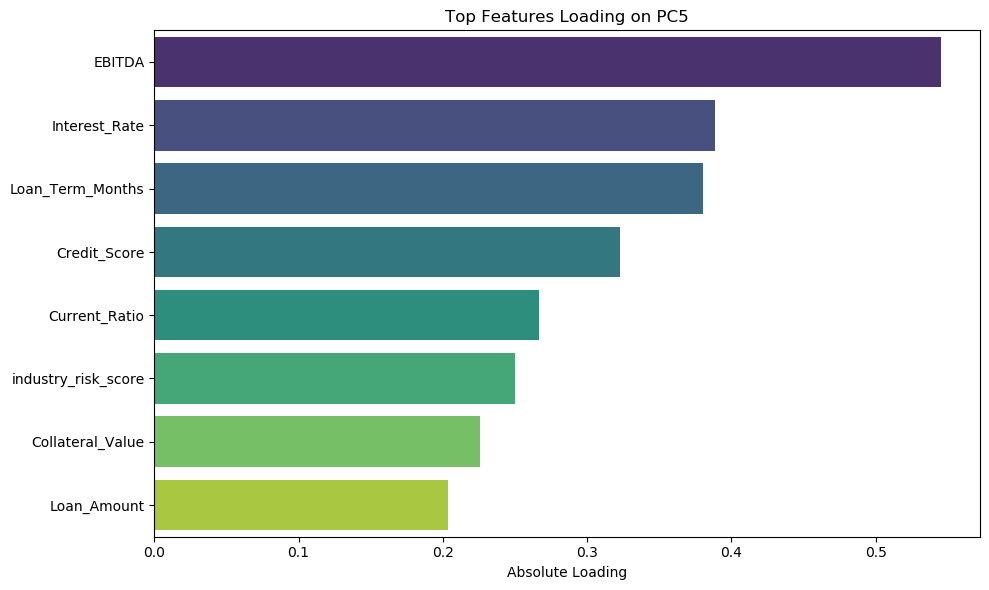

In [18]:
import seaborn as sns
for i in range(1, 6):  # First 5 PCs
    pc = f'PC{i}'
    top_features = loadings[pc].abs().sort_values(ascending=False).head(8)
    print(f"\nTop 8 Features for {pc}:")
    print(top_features.round(4))
    
    # Visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
    plt.title(f'Top Features Loading on {pc}')
    plt.xlabel('Absolute Loading')
    plt.tight_layout()
    plt.show()